In [123]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

## Question 1

In [148]:
T = 5

A = np.array([
    [1.2, 0.2], 
    [0.7, 1.2]
])

z_initial = np.array([
    [.2, .3], 
    [.2, .3]
])

## Question 2

### Method 1

In [149]:
Z = np.zeros((T + 1, 2, 2))

Z[0] = z_initial

In [150]:
for t in range(1, T + 1):
    for row in range(2):
        interval_1 = [min(A[row, 0] * Z[t - 1, 0]), max(A[row, 0] * Z[t - 1, 0])]
        interval_2 = [min(A[row, 1] * Z[t - 1, 1]), max(A[row, 1] * Z[t - 1, 1])]

        Z[t, row] = [
            min(interval_1) + min(interval_2),
            max(interval_1) + max(interval_2)
        ]


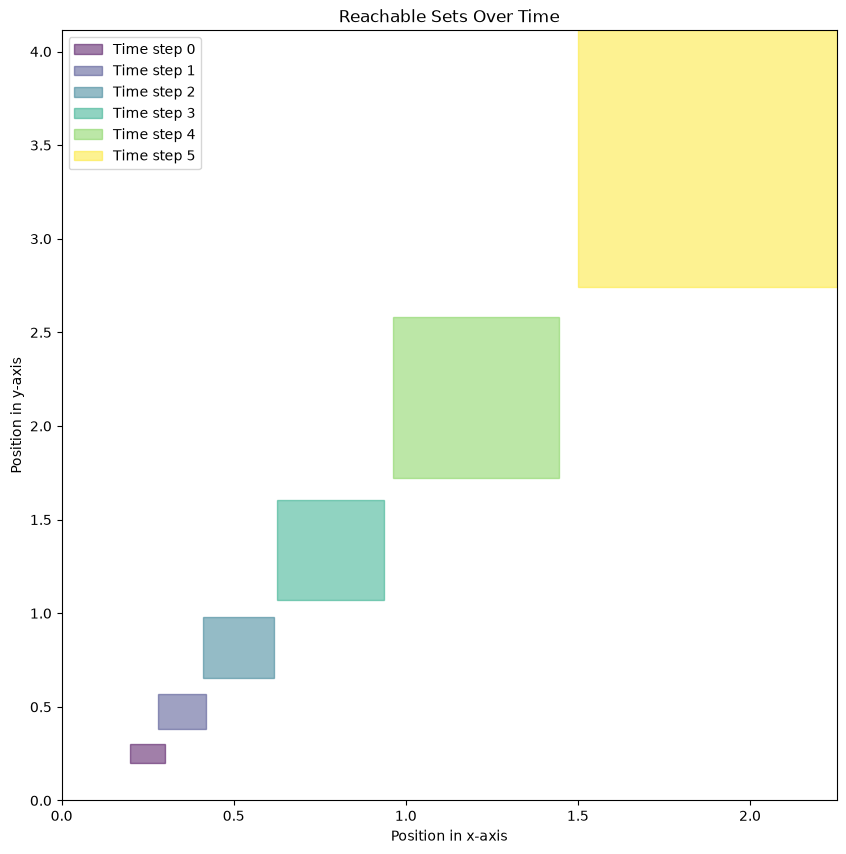

In [151]:
# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 10))

# Define colors for each time step
colors = plt.cm.viridis(np.linspace(0, 1, T + 1))

# Loop through each time step and plot the rectangles
for t in range(T + 1):
    # Get the lower left and upper right corners for the rectangle
    lower_left = [Z[t, 0, 0], Z[t, 1, 0]]
    upper_right = [Z[t, 0, 1], Z[t, 1, 1]]
    
    # Create a rectangle patch
    rect = patches.Rectangle((lower_left[0], lower_left[1]), upper_right[0] - lower_left[0], upper_right[1] - lower_left[1],
                             color=colors[t], alpha=0.5, label=f'Time step {t}') 

    
    # Add the rectangle to the plot
    ax.add_patch(rect)


# Set the limits and labels for the plot
ax.set_xlim(0, np.max(Z[:, 0,:]))
ax.set_ylim(0, np.max(Z[:, 1,:]))
ax.set_title('Reachable Sets Over Time')
ax.set_xlabel('Position in x-axis')
ax.set_ylabel('Position in y-axis')
ax.legend()
plt.show() 

### Method 2

In [152]:
Z_vertices = np.zeros((T + 1, 4, 2))

Z_vertices[0] = np.array([
    [z_initial[0, 0], z_initial[1, 0]],  # Lower left
    [z_initial[0, 1], z_initial[1, 0]],  # Lower right
    [z_initial[0, 1], z_initial[1, 1]],  # Upper right
    [z_initial[0, 0], z_initial[1, 1]]   # Upper left
])

print("Z_vertices[0]:", Z_vertices[0])

Z_vertices[0]: [[0.2 0.2]
 [0.3 0.2]
 [0.3 0.3]
 [0.2 0.3]]


In [153]:
A @ Z_vertices[0][1]

for t in range(1, T + 1):
    for v in range(4):
        Z_vertices[t, v] = A @ Z_vertices[t - 1, v]


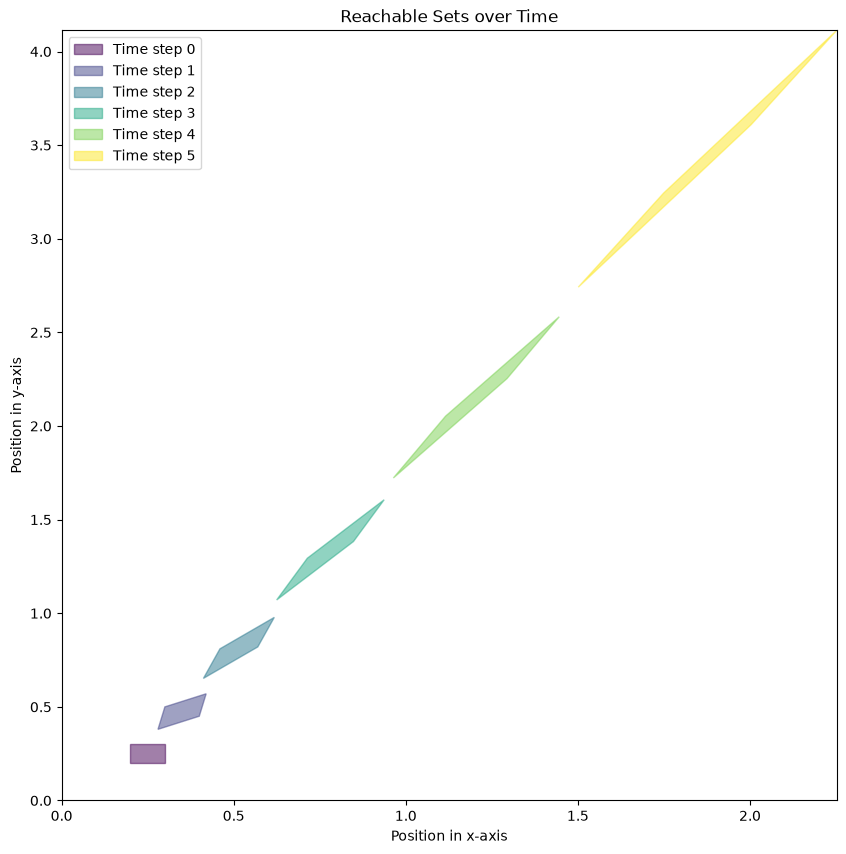

In [154]:
fig2, ax2 = plt.subplots(figsize=(10, 10))

# Loop through each time step and plot the polygons
for t in range(T + 1):
    polygon = patches.Polygon(Z_vertices[t], closed=True, color=colors[t], alpha=0.5, label=f'Time step {t}')
    ax2.add_patch(polygon)


ax2.set_xlim(0, np.max(Z_vertices[:, :, 0]))
ax2.set_ylim(0, np.max(Z_vertices[:, :, 1]))
ax2.set_title('Reachable Sets over Time')
ax2.set_xlabel('Position in x-axis')
ax2.set_ylabel('Position in y-axis')
ax2.legend()
plt.show() 

## Question 3

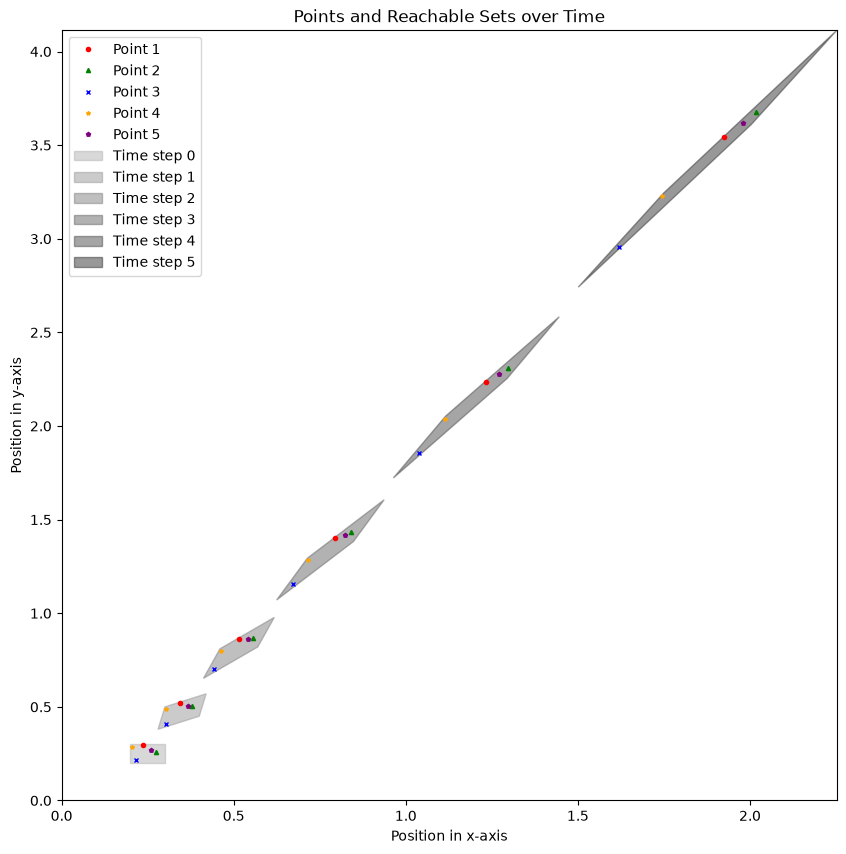

In [155]:
# Create 5 random points that fall between z_initial and calculate their positions over time. Plot the points and their trajectories over time. Also plot the reachable sets over time using Z_vertices. Use different colors for each point and its trajectory.
np.random.seed(42)

points = np.zeros((T+ 1, 5, 2))

for i in range(5):
    points[0, i, 0] = np.random.uniform(z_initial[0, 0], z_initial[0, 1])
    points[0, i, 1] = np.random.uniform(z_initial[1, 0], z_initial[1, 1])

for t in range(1, T + 1):
    for i in range(5):
        points[t, i] = A @ points[t - 1, i]


fig3, ax3 = plt.subplots(figsize=(10, 10))

# Plot the points only, they should have different shades of red.
colors_points = ['Red', 'Green', 'Blue', 'Orange', 'Purple']
markers = ['o', '^', 'x', '*', 'p']

for i in range(5):
    ax3.plot(
        points[:, i, 0],
        points[:, i, 1],
        color=colors_points[i],
        marker=markers[i],
        markersize=3,
        linestyle='None',
        label=f'Point {i + 1}'
    )


# Plot the reachable sets
colors_reachable_sets = plt.cm.gray(np.linspace(0.7, 0.2, T + 1))
for t in range(T+1):
    polygon = patches.Polygon(Z_vertices[t], closed=True, color=colors_reachable_sets[t], alpha=0.5, label=f'Time step {t}')
    ax3.add_patch(polygon)

ax3.set_xlim(0, np.max(Z_vertices[:, :, 0]))
ax3.set_ylim(0, np.max(Z_vertices[:, :, 1]))
ax3.set_title('Points and Reachable Sets over Time')
ax3.set_xlabel('Position in x-axis')
ax3.set_ylabel('Position in y-axis')
ax3.legend()
plt.show()
